# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name:



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [22]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 1. Business Understanding
Goal: # 1. Business Understanding

## Project Goal

The goal of this project is to develop a machine learning classification model that predicts whether a student may be at risk of depression based on academic, lifestyle, financial and personal factors.

The target variable is `Depression`, which contains two possible classes:

- `Yes` – the student is classified as having depression.
- `No` – the student is classified as not having depression.

The model will use factors such as academic pressure, study satisfaction, sleep duration, dietary habits, study hours, financial stress, family history of mental illness and previous suicidal thoughts.

## Business Problem

Depression can negatively affect students' academic performance, attendance, relationships and general well-being. Educational institutions may not always identify students who require support early enough.

A machine learning model could support student-wellness teams by identifying patterns associated with depression risk. Students predicted to be at higher risk could then be prioritised for further screening or support.

## Business Value

The model may help educational institutions:

1. Identify potentially at-risk students earlier.
2. Help counsellors prioritise students for further assessment.
3. Better understand factors associated with student depression.
4. Plan targeted student-wellness programmes.
5. Reduce reliance on fully manual screening.

## Intended Users

The intended users are:

- School counsellors
- Student-wellness teams
- Educational administrators
- Student-support departments

## Machine Learning Task

This is a supervised binary classification problem because the model learns from labelled student records and predicts one of two classes: depression or no depression.

## Limitation

This project is a student-wellness risk-screening prototype. It is not a medical diagnosis and should not replace assessment by a qualified mental-health professional.

# 2. Data Understanding

## 2.1 Load dataset

In [23]:
## Read *.csv file into pandas DataFrame
## Read *.csv file into pandas DataFrame
# Load the dataset from the same folder as the notebook
file_path = r"c:\Users\haniy\OneDrive\Desktop\MLDP\Depression Student Dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()

Dataset loaded successfully.
Number of rows: 502
Number of columns: 11


,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,More than 8 hours,Healthy,Yes,4,2,Yes,No


## 2.2 Summary Statistics

In [38]:
## Understand the type of variable for each column
## Display column names, data types and non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 502 non-null    object 
 1   Age                                    502 non-null    int64  
 2   Academic Pressure                      502 non-null    float64
 3   Study Satisfaction                     502 non-null    float64
 4   Sleep Duration                         502 non-null    object 
 5   Dietary Habits                         502 non-null    object 
 6   Have you ever had suicidal thoughts ?  502 non-null    object 
 7   Study Hours                            502 non-null    int64  
 8   Financial Stress                       502 non-null    int64  
 9   Family History of Mental Illness       502 non-null    object 
 10  Depression                             502 non-null    object 
dtypes: flo

In [25]:
## Check for missing data
## Check missing values in each column

df.isnull().sum()

Gender                                   0
Age                                      0
Academic Pressure                        0
Study Satisfaction                       0
Sleep Duration                           0
Dietary Habits                           0
Have you ever had suicidal thoughts ?    0
Study Hours                              0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [26]:
## Check for duplicated records

duplicate_count = df.duplicated().sum()

print("Number of duplicated rows:", duplicate_count)

Number of duplicated rows: 0


In [27]:
## Display summary statistics for all variables

df.describe(include="all")

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
count,502,502.000000,502.000000,502.000000,502,502,502,502.000000,502.000000,502,502
unique,2,NaN,NaN,NaN,4,3,2,NaN,NaN,2,2
top,Male,NaN,NaN,NaN,7-8 hours,Moderate,Yes,NaN,NaN,No,Yes
freq,267,NaN,NaN,NaN,128,172,260,NaN,NaN,265,252
mean,NaN,26.241036,3.003984,3.075697,NaN,NaN,NaN,6.404382,2.928287,NaN,NaN
std,NaN,4.896501,1.390007,1.373490,NaN,NaN,NaN,3.742434,1.425053,NaN,NaN
min,NaN,18.000000,1.000000,1.000000,NaN,NaN,NaN,0.000000,1.000000,NaN,NaN
25%,NaN,22.000000,2.000000,2.000000,NaN,NaN,NaN,3.000000,2.000000,NaN,NaN
50%,NaN,26.500000,3.000000,3.000000,NaN,NaN,NaN,7.000000,3.000000,NaN,NaN
75%,NaN,30.000000,4.000000,4.000000,NaN,NaN,NaN,10.000000,4.000000,NaN,NaN


In [28]:
## Check the unique values in all categorical columns

categorical_columns_check = df.select_dtypes(
    include=["object", "category"]
).columns

for column in categorical_columns_check:
    print(f"\n{column}:")
    print(df[column].value_counts())


Gender:
Gender
Male      267
Female    235
Name: count, dtype: int64

Sleep Duration:
Sleep Duration
7-8 hours            128
More than 8 hours    128
5-6 hours            123
Less than 5 hours    123
Name: count, dtype: int64

Dietary Habits:
Dietary Habits
Moderate     172
Unhealthy    169
Healthy      161
Name: count, dtype: int64

Have you ever had suicidal thoughts ?:
Have you ever had suicidal thoughts ?
Yes    260
No     242
Name: count, dtype: int64

Family History of Mental Illness:
Family History of Mental Illness
No     265
Yes    237
Name: count, dtype: int64

Depression:
Depression
Yes    252
No     250
Name: count, dtype: int64


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

Depression
Yes    252
No     250
Name: count, dtype: int64


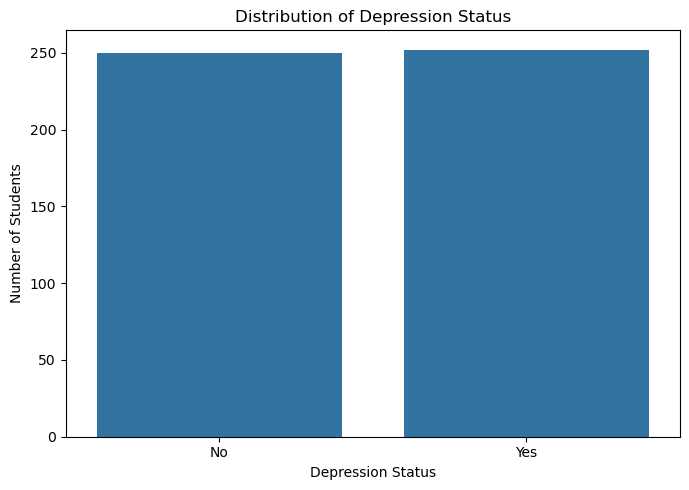

In [39]:
## Display the target distribution

target_counts = df["Depression"].value_counts()

print(target_counts)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Depression"
)

plt.title("Distribution of Depression Status")
plt.xlabel("Depression Status")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

### 2.3.1.2 Understanding distribution of features

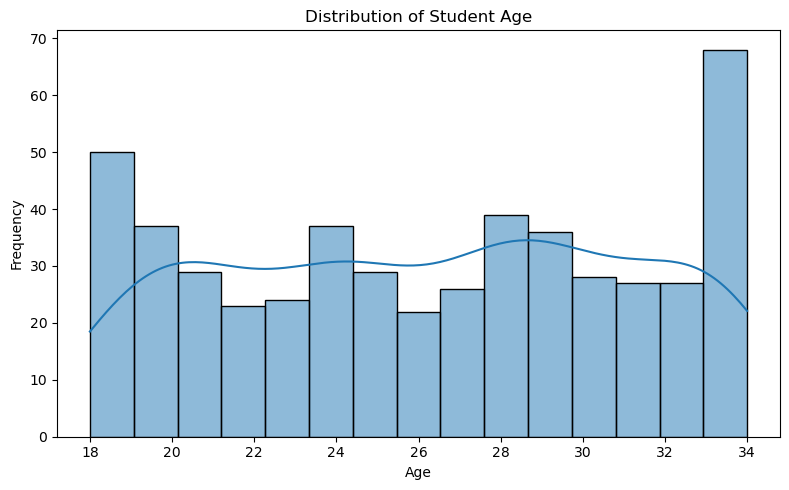

In [40]:
## Understanding distribution of features
## Understand the distribution of student age

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=15,
    kde=True
)

plt.title("Distribution of Student Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

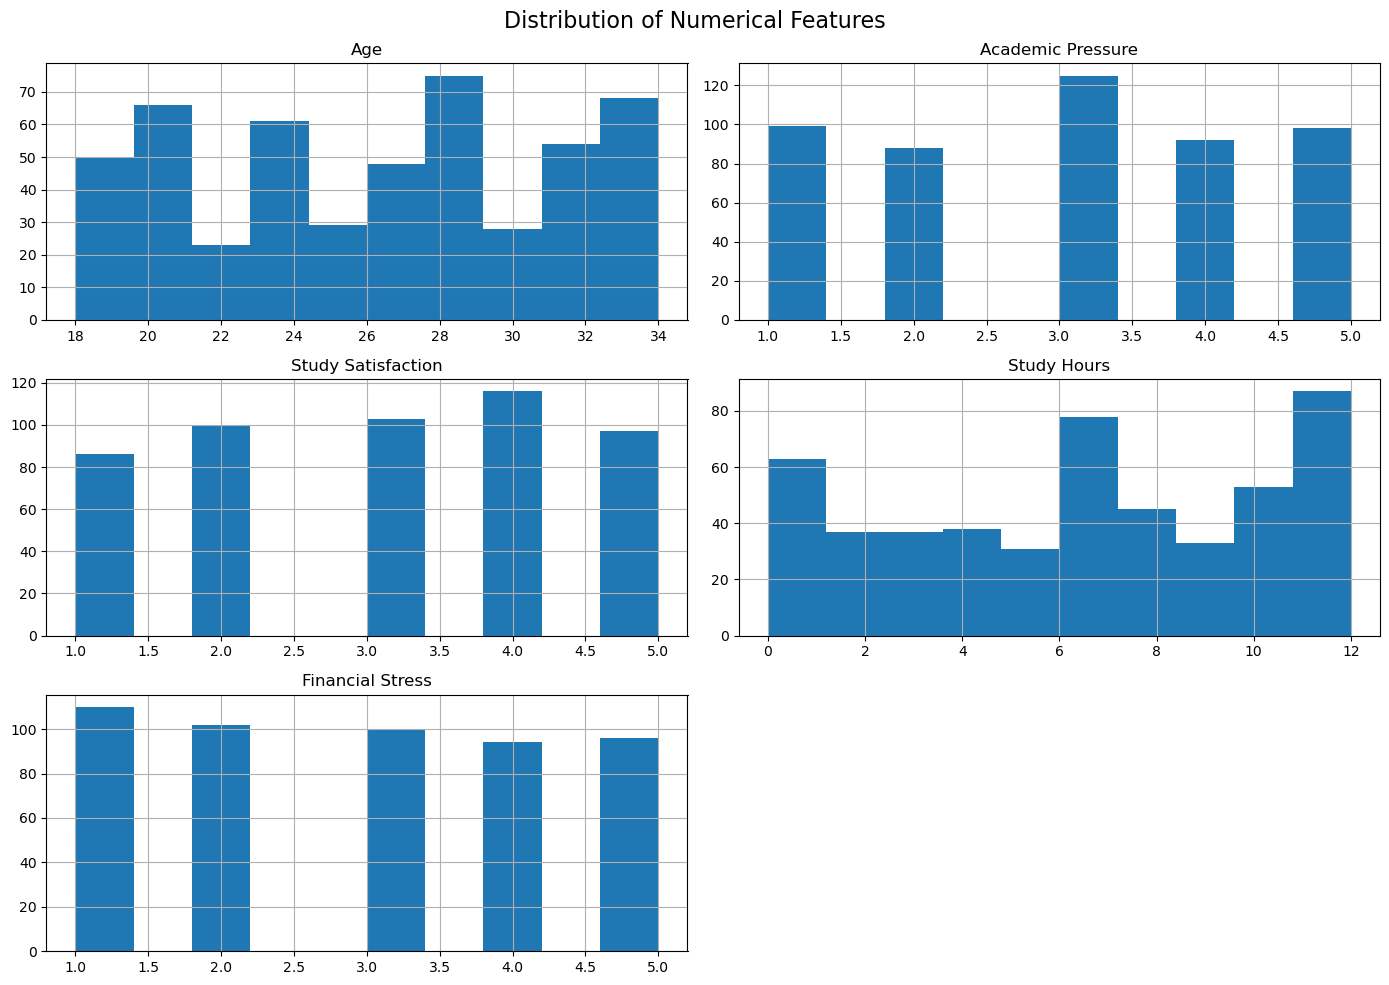

In [42]:
## Display the distributions of all numerical features

numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

df[numerical_features].hist(
    figsize=(14, 10),
    bins=10
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()

### 2.3.2 Understanding relationship between variables

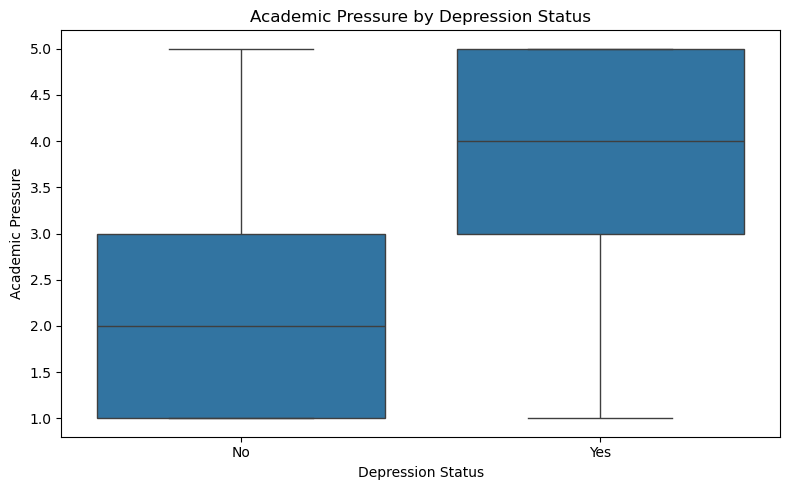

In [59]:
## Understanding relationship between variables

## Understand relationship between Academic Pressure and Depression

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Depression",
    y="Academic Pressure"
)

plt.title("Academic Pressure by Depression Status")
plt.xlabel("Depression Status")
plt.ylabel("Academic Pressure")

plt.tight_layout()
plt.show()

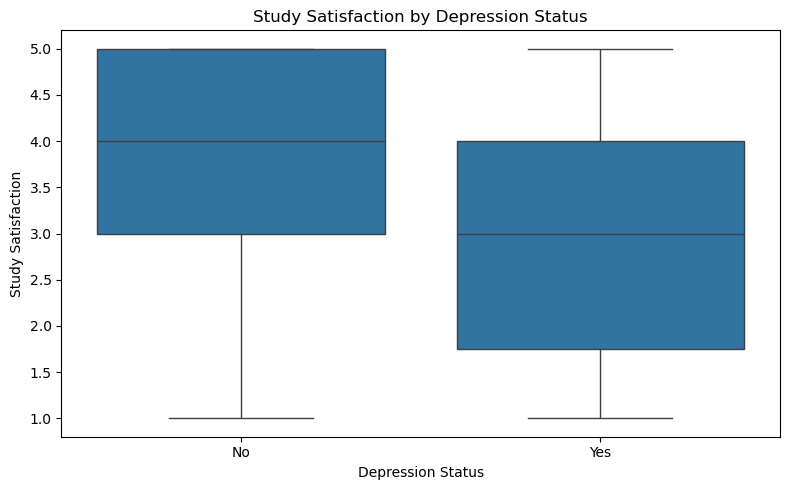

In [53]:
## Understand relationship between Study Satisfaction and Depression

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Depression",
    y="Study Satisfaction"
)

plt.title("Study Satisfaction by Depression Status")
plt.xlabel("Depression Status")
plt.ylabel("Study Satisfaction")

plt.tight_layout()
plt.show()

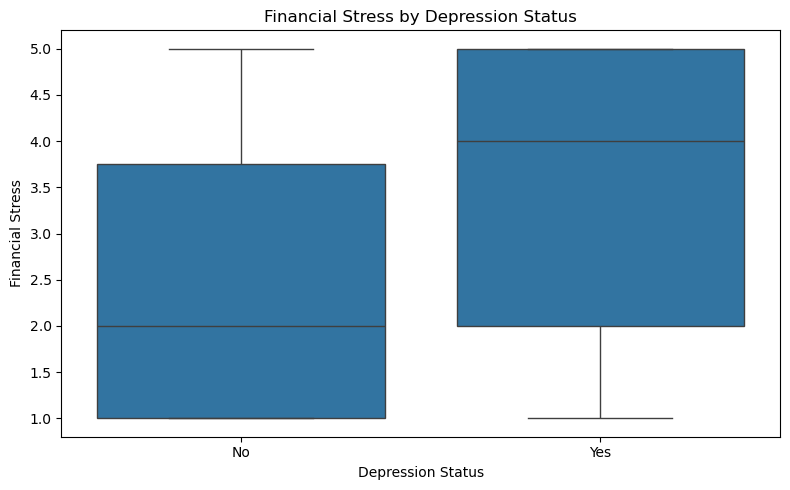

In [55]:
## Understand relationship between Financial Stress and Depression

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Depression",
    y="Financial Stress"
)

plt.title("Financial Stress by Depression Status")
plt.xlabel("Depression Status")
plt.ylabel("Financial Stress")

plt.tight_layout()
plt.show()

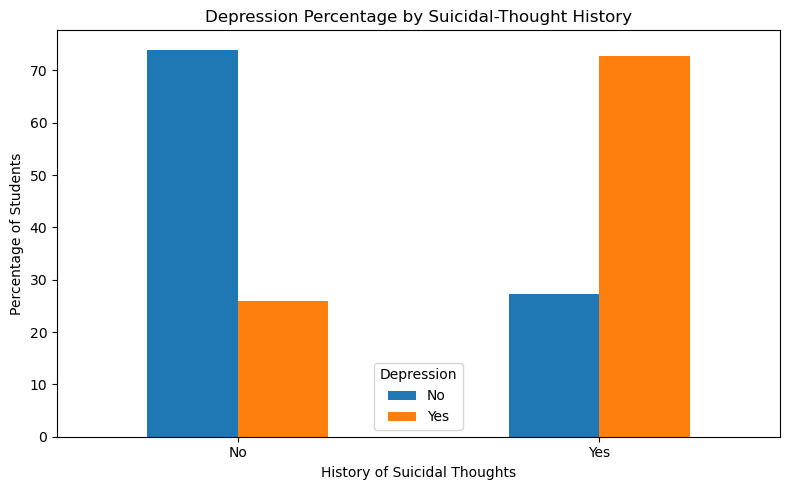

In [57]:
## Understand relationship between Suicidal Thoughts and Depression

thoughts_table = pd.crosstab(
    df["Have you ever had suicidal thoughts ?"],
    df["Depression"],
    normalize="index"
) * 100

thoughts_table.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Depression Percentage by Suicidal-Thought History")
plt.xlabel("History of Suicidal Thoughts")
plt.ylabel("Percentage of Students")
plt.xticks(rotation=0)
plt.legend(title="Depression")

plt.tight_layout()
plt.show()

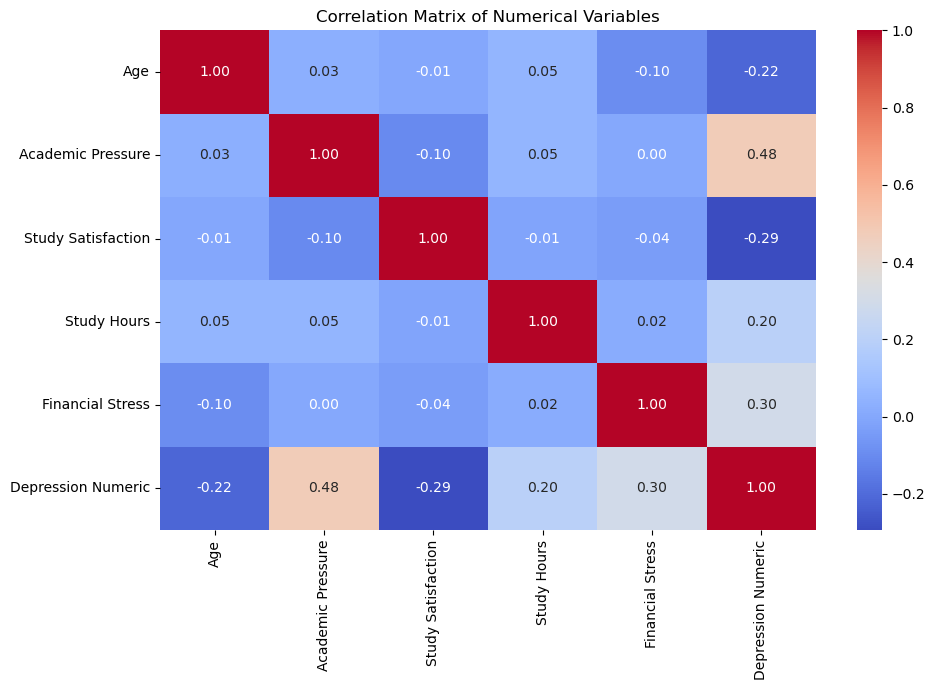

In [58]:
## Understand relationships between numerical variables

df_correlation = df.copy()

df_correlation["Depression Numeric"] = (
    df_correlation["Depression"]
    .map({
        "No": 0,
        "Yes": 1
    })
)

correlation_matrix = (
    df_correlation
    .select_dtypes(include=["number"])
    .corr()
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

# 3. Data Preparation

## 3.1 Data Cleaning

In [70]:
## Create a copy of the original dataset before cleaning

df_cleaned = df.copy()


## Rename the long column for easier coding

df_cleaned = df_cleaned.rename(
    columns={
        "Have you ever had suicidal thoughts ?":
        "Suicidal Thoughts"
    }
)


## Remove extra spaces from categorical values

text_columns = df_cleaned.select_dtypes(
    include=["object", "category"]
).columns

for column in text_columns:
    df_cleaned[column] = (
        df_cleaned[column]
        .astype(str)
        .str.strip()
    )


## Remove duplicated records

df_cleaned = (
    df_cleaned
    .drop_duplicates()
    .reset_index(drop=True)
)


## Check cleaning results

print("Rows after cleaning:", len(df_cleaned))

print(
    "Remaining duplicated rows:",
    df_cleaned.duplicated().sum()
)

print(
    "Remaining missing values:",
    df_cleaned.isnull().sum().sum()
)

print(
    "Cleaned dataset shape:",
    df_cleaned.shape
)

df_cleaned.head()

Rows after cleaning: 502
Remaining duplicated rows: 0
Remaining missing values: 0
Cleaned dataset shape: (502, 11)


,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Suicidal Thoughts,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,More than 8 hours,Healthy,Yes,4,2,Yes,No


### 3.1.1 Feature Engineering

In [71]:
## Create meaningful engineered features


## Feature 1:
## Combine academic pressure and financial stress

df_cleaned["Total Stress Score"] = (
    df_cleaned["Academic Pressure"]
    + df_cleaned["Financial Stress"]
)


## Feature 2:
## Measure whether pressure is higher than satisfaction

df_cleaned["Pressure Satisfaction Gap"] = (
    df_cleaned["Academic Pressure"]
    - df_cleaned["Study Satisfaction"]
)


## Feature 3:
## Group study hours into workload categories

df_cleaned["Study Load Category"] = pd.cut(
    df_cleaned["Study Hours"],
    bins=[
        -1,
        4,
        8,
        float("inf")
    ],
    labels=[
        "Low",
        "Moderate",
        "High"
    ]
)


## Display the engineered features

print("Feature engineering completed successfully.")

print(
    "Dataset shape after feature engineering:",
    df_cleaned.shape
)

df_cleaned[
    [
        "Academic Pressure",
        "Financial Stress",
        "Total Stress Score",
        "Study Satisfaction",
        "Pressure Satisfaction Gap",
        "Study Hours",
        "Study Load Category"
    ]
].head()

Feature engineering completed successfully.
Dataset shape after feature engineering: (502, 14)


,Academic Pressure,Financial Stress,Total Stress Score,Study Satisfaction,Pressure Satisfaction Gap,Study Hours,Study Load Category
0,2.0,2,4.0,4.0,-2.0,9,High
1,4.0,1,5.0,5.0,-1.0,7,Moderate
2,1.0,4,5.0,3.0,-2.0,10,High
3,1.0,2,3.0,4.0,-3.0,7,Moderate
4,1.0,2,3.0,5.0,-4.0,4,Low


In [65]:
## Separate input features and target variable

X = df_cleaned.drop(
    columns=["Depression"]
)

y = df_cleaned["Depression"].map({
    "No": 0,
    "Yes": 1
})


## Check X and y

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nIs Depression inside X?")
print("Depression" in X.columns)

print("\nDo X and y indices match?")
print(X.index.equals(y.index))

print("\nMissing values in X:")
print(X.isnull().sum().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

X shape: (502, 13)
y shape: (502,)

Target distribution:
Depression
1    252
0    250
Name: count, dtype: int64

Is Depression inside X?
False

Do X and y indices match?
True

Missing values in X:
0

Missing values in y:
0


## OHE and Preprocessing

In [73]:
## Import preprocessing tools

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer


## Identify numerical and categorical columns using X

numerical_columns = X.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()


print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Age', 'Academic Pressure', 'Study Satisfaction', 'Study Hours', 'Financial Stress', 'Total Stress Score', 'Pressure Satisfaction Gap']

Categorical columns:
['Gender', 'Sleep Duration', 'Dietary Habits', 'Suicidal Thoughts', 'Family History of Mental Illness', 'Study Load Category']


In [74]:
## Numerical preprocessing
## Fill missing numerical values using the median
## and standardise numerical features

numerical_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


## Categorical preprocessing
## Fill missing categorical values using the most frequent value
## and apply One-Hot Encoding

categorical_preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


## Apply the correct preprocessing to each column type

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_preprocessor,
            numerical_columns
        ),
        (
            "categorical",
            categorical_preprocessor,
            categorical_columns
        )
    ]
)


print("Preprocessing and OHE created successfully.")

Preprocessing and OHE created successfully.


In [75]:
## Apply preprocessing and OHE to all features in X

X_encoded_array = preprocessor.fit_transform(X)


## Retrieve feature names created after preprocessing

encoded_feature_names = (
    preprocessor.get_feature_names_out()
)


## Convert encoded array back into a DataFrame

X_encoded = pd.DataFrame(
    X_encoded_array,
    columns=encoded_feature_names,
    index=X.index
)


## Display preprocessing results

print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)

print(
    "\nNumber of features before OHE:",
    X.shape[1]
)

print(
    "Number of features after OHE:",
    X_encoded.shape[1]
)

print(
    "\nMissing values after preprocessing:",
    X_encoded.isnull().sum().sum()
)

print(
    "Do X_encoded and y indices match?",
    X_encoded.index.equals(y.index)
)

X_encoded.head()

Original X shape: (502, 13)
Encoded X shape: (502, 23)

Number of features before OHE: 13
Number of features after OHE: 23

Missing values after preprocessing: 0
Do X_encoded and y indices match? True


,numerical__Age,numerical__Academic Pressure,numerical__Study Satisfaction,numerical__Study Hours,numerical__Financial Stress,numerical__Total Stress Score,numerical__Pressure Satisfaction Gap,categorical__Gender_Female,categorical__Gender_Male,categorical__Sleep Duration_5-6 hours,...,categorical__Dietary Habits_Healthy,categorical__Dietary Habits_Moderate,categorical__Dietary Habits_Unhealthy,categorical__Suicidal Thoughts_No,categorical__Suicidal Thoughts_Yes,categorical__Family History of Mental Illness_No,categorical__Family History of Mental Illness_Yes,categorical__Study Load Category_High,categorical__Study Load Category_Low,categorical__Study Load Category_Moderate
0,0.359587,-0.723007,0.673631,0.694256,-0.652055,-0.970081,-0.941127,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
1,0.359587,0.717269,1.402429,0.159311,-1.354484,-0.468039,-0.453063,0.0,1.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,-0.253706,-1.443146,-0.055168,0.961728,0.752802,-0.468039,-0.941127,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
3,-0.662569,-1.443146,0.673631,0.159311,-0.652055,-1.472124,-1.429190,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,0.972881,-1.443146,1.402429,-0.643106,-0.652055,-1.472124,-1.917254,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [76]:
## Display all feature names after preprocessing and OHE

for feature_name in X_encoded.columns:
    print(feature_name)

numerical__Age
numerical__Academic Pressure
numerical__Study Satisfaction
numerical__Study Hours
numerical__Financial Stress
numerical__Total Stress Score
numerical__Pressure Satisfaction Gap
categorical__Gender_Female
categorical__Gender_Male
categorical__Sleep Duration_5-6 hours
categorical__Sleep Duration_7-8 hours
categorical__Sleep Duration_Less than 5 hours
categorical__Sleep Duration_More than 8 hours
categorical__Dietary Habits_Healthy
categorical__Dietary Habits_Moderate
categorical__Dietary Habits_Unhealthy
categorical__Suicidal Thoughts_No
categorical__Suicidal Thoughts_Yes
categorical__Family History of Mental Illness_No
categorical__Family History of Mental Illness_Yes
categorical__Study Load Category_High
categorical__Study Load Category_Low
categorical__Study Load Category_Moderate


## 3.2 Train-Test Split

In [77]:
## Import train-test split

from sklearn.model_selection import train_test_split


## Split encoded data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## Display split results

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nTraining indices match:")
print(X_train.index.equals(y_train.index))

print("\nTesting indices match:")
print(X_test.index.equals(y_test.index))

print("\nMissing values in X_train:")
print(X_train.isnull().sum().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum().sum())

Training features: (401, 23)
Testing features: (101, 23)
Training target: (401,)
Testing target: (101,)

Training target distribution:
Depression
1    201
0    200
Name: count, dtype: int64

Testing target distribution:
Depression
1    51
0    50
Name: count, dtype: int64

Training indices match:
True

Testing indices match:
True

Missing values in X_train:
0

Missing values in X_test:
0


# 4. Modelling

### 4.2 Train Model

In [78]:
## Initialise and train model
## Import classification models

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)


## Initialise baseline model

baseline_model = DummyClassifier(
    strategy="most_frequent"
)


## Initialise Logistic Regression

logistic_regression_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


## Initialise Decision Tree

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)


## Initialise Random Forest

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


## Initialise Gradient Boosting Tree

gradient_boosting_model = GradientBoostingClassifier(
    random_state=42
)


## Store all models in a dictionary

models = {
    "Baseline": baseline_model,
    "Logistic Regression": logistic_regression_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting Tree": gradient_boosting_model
}


print("All models initialised successfully.")

All models initialised successfully.


In [79]:
## Train all classification models

for model_name, model in models.items():

    print(f"Training {model_name}...")

    model.fit(
        X_train,
        y_train
    )

    print(
        f"{model_name} trained successfully.\n"
    )

Training Baseline...
Baseline trained successfully.

Training Logistic Regression...
Logistic Regression trained successfully.

Training Decision Tree...
Decision Tree trained successfully.

Training Random Forest...
Random Forest trained successfully.

Training Gradient Boosting Tree...
Gradient Boosting Tree trained successfully.



# 5. Model Evaluation

In [80]:
## Evaluate model
## Import classification evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


In [81]:
## Evaluate all models using testing data

model_results = []

for model_name, model in models.items():

    ## Generate predicted classes

    predictions = model.predict(X_test)


    ## Generate probabilities when available

    if hasattr(model, "predict_proba"):

        probabilities = model.predict_proba(
            X_test
        )[:, 1]

        roc_auc = roc_auc_score(
            y_test,
            probabilities
        )

    else:

        roc_auc = np.nan


    ## Calculate metrics

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )


    ## Store results

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })


## Convert results into a DataFrame

results_df = pd.DataFrame(
    model_results
)


## Sort using F1-score

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)


## Round results

results_df[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
] = results_df[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
].round(4)


results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000
1,Gradient Boosting Tree,0.9307,0.9231,0.9412,0.9320,0.9871
2,Random Forest,0.9208,0.8909,0.9608,0.9245,0.9802
3,Decision Tree,0.9010,0.9184,0.8824,0.9000,0.9012
4,Baseline,0.5050,0.5050,1.0000,0.6711,0.5000


In [82]:
## Select the model with the highest F1-score

best_model_row = results_df.iloc[0]

best_model_name = best_model_row["Model"]

best_initial_model = models[
    best_model_name
]


print("Best initial model:", best_model_name)

print(
    "Accuracy:",
    best_model_row["Accuracy"]
)

print(
    "Precision:",
    best_model_row["Precision"]
)

print(
    "Recall:",
    best_model_row["Recall"]
)

print(
    "F1 Score:",
    best_model_row["F1 Score"]
)

print(
    "ROC-AUC:",
    best_model_row["ROC-AUC"]
)

Best initial model: Logistic Regression
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
ROC-AUC: 1.0


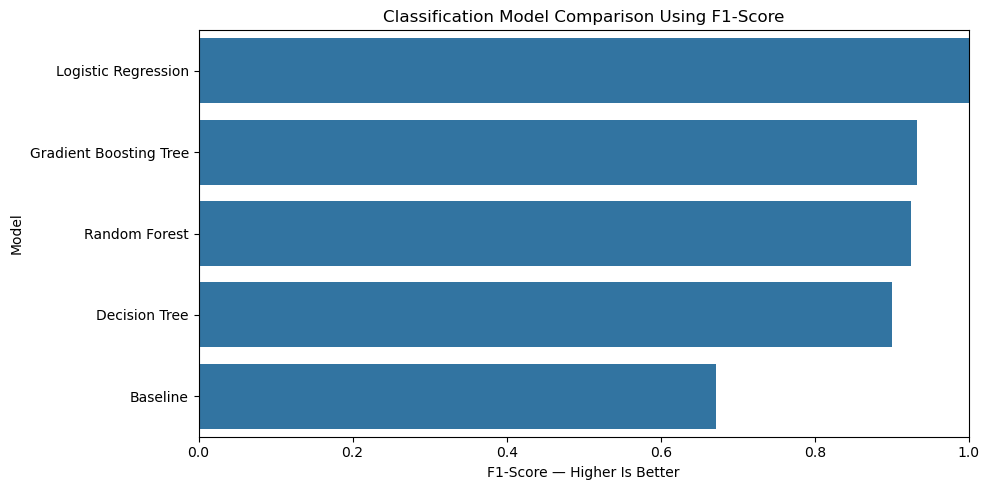

In [83]:
## Compare F1-score across all models

plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="F1 Score",
    y="Model"
)

plt.title(
    "Classification Model Comparison Using F1-Score"
)

plt.xlabel(
    "F1-Score — Higher Is Better"
)

plt.ylabel("Model")

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

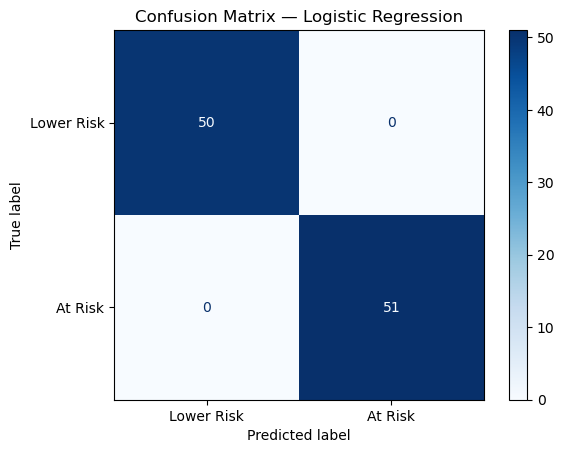

In [84]:
## Generate predictions using the best initial model

best_initial_predictions = (
    best_initial_model.predict(X_test)
)


## Display confusion matrix

confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(
        y_test,
        best_initial_predictions
    ),
    display_labels=[
        "Lower Risk",
        "At Risk"
    ]
)

confusion_display.plot(
    cmap="Blues"
)

plt.title(
    f"Confusion Matrix — {best_model_name}"
)

plt.show()

In [85]:
## Display detailed classification results

print(
    classification_report(
        y_test,
        best_initial_predictions,
        target_names=[
            "Lower Risk",
            "At Risk"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Lower Risk       1.00      1.00      1.00        50
     At Risk       1.00      1.00      1.00        51

    accuracy                           1.00       101
   macro avg       1.00      1.00      1.00       101
weighted avg       1.00      1.00      1.00       101



## Iterative model development


In [87]:
## Compare training and testing performance

fit_results = []

for model_name, model in models.items():

    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    train_accuracy = accuracy_score(
        y_train,
        train_predictions
    )

    test_accuracy = accuracy_score(
        y_test,
        test_predictions
    )

    train_f1 = f1_score(
        y_train,
        train_predictions,
        zero_division=0
    )

    test_f1 = f1_score(
        y_test,
        test_predictions,
        zero_division=0
    )

    fit_results.append({
        "Model": model_name,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy,
        "Training F1": train_f1,
        "Testing F1": test_f1
    })


fit_results_df = pd.DataFrame(
    fit_results
)


fit_results_df[
    [
        "Training Accuracy",
        "Testing Accuracy",
        "Training F1",
        "Testing F1"
    ]
] = fit_results_df[
    [
        "Training Accuracy",
        "Testing Accuracy",
        "Training F1",
        "Testing F1"
    ]
].round(4)


fit_results_df

,Model,Training Accuracy,Testing Accuracy,Training F1,Testing F1
0,Baseline,0.5012,0.5050,0.6678,0.6711
1,Logistic Regression,0.9900,1.0000,0.9900,1.0000
2,Decision Tree,1.0000,0.9010,1.0000,0.9000
3,Random Forest,1.0000,0.9208,1.0000,0.9245
4,Gradient Boosting Tree,1.0000,0.9307,1.0000,0.9320


In [88]:
## Define engineered features

engineered_features = [
    "Total Stress Score",
    "Pressure Satisfaction Gap",
    "Study Load Category"
]


## Create dataset containing original features only

X_original = df_cleaned.drop(
    columns=[
        "Depression"
    ] + engineered_features
)


## Identify original numerical and categorical columns

original_numerical_columns = (
    X_original.select_dtypes(
        include=["number"]
    ).columns.tolist()
)

original_categorical_columns = (
    X_original.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()
)


## Create preprocessing for original features

original_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_preprocessor,
            original_numerical_columns
        ),
        (
            "categorical",
            categorical_preprocessor,
            original_categorical_columns
        )
    ]
)


## Apply preprocessing and OHE

X_original_encoded_array = (
    original_preprocessor.fit_transform(
        X_original
    )
)


X_original_encoded = pd.DataFrame(
    X_original_encoded_array,
    columns=original_preprocessor.get_feature_names_out(),
    index=X_original.index
)


## Split original-feature data

X_train_original, X_test_original, \
y_train_original, y_test_original = train_test_split(
    X_original_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## Train Random Forest using original features

original_feature_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

original_feature_model.fit(
    X_train_original,
    y_train_original
)


## Generate predictions

original_feature_predictions = (
    original_feature_model.predict(
        X_test_original
    )
)

engineered_feature_predictions = (
    random_forest_model.predict(X_test)
)


## Create comparison table

feature_comparison = pd.DataFrame({
    "Feature Set": [
        "Original Features",
        "Original + Engineered Features"
    ],

    "Accuracy": [
        accuracy_score(
            y_test_original,
            original_feature_predictions
        ),
        accuracy_score(
            y_test,
            engineered_feature_predictions
        )
    ],

    "Precision": [
        precision_score(
            y_test_original,
            original_feature_predictions,
            zero_division=0
        ),
        precision_score(
            y_test,
            engineered_feature_predictions,
            zero_division=0
        )
    ],

    "Recall": [
        recall_score(
            y_test_original,
            original_feature_predictions,
            zero_division=0
        ),
        recall_score(
            y_test,
            engineered_feature_predictions,
            zero_division=0
        )
    ],

    "F1 Score": [
        f1_score(
            y_test_original,
            original_feature_predictions,
            zero_division=0
        ),
        f1_score(
            y_test,
            engineered_feature_predictions,
            zero_division=0
        )
    ]
})


feature_comparison[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
] = feature_comparison[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
].round(4)


feature_comparison

,Feature Set,Accuracy,Precision,Recall,F1 Score
0,Original Features,0.9109,0.8750,0.9608,0.9159
1,Original + Engineered Features,0.9208,0.8909,0.9608,0.9245


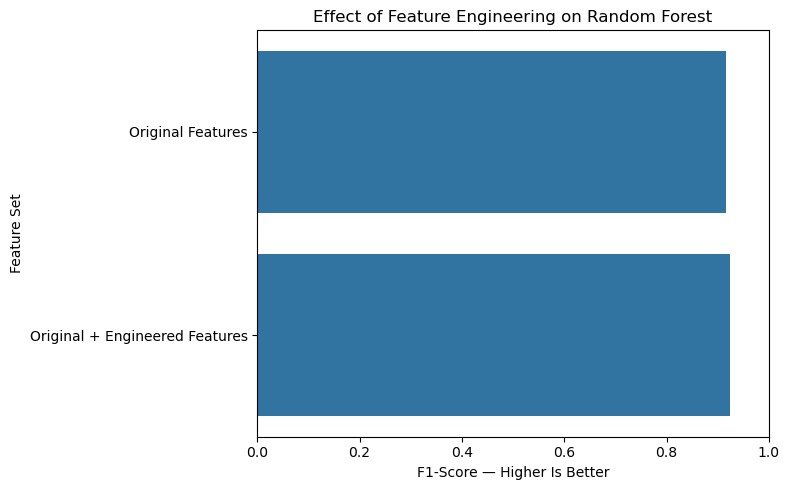

In [89]:
## Compare F1-score before and after feature engineering

plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_comparison,
    x="F1 Score",
    y="Feature Set"
)

plt.title(
    "Effect of Feature Engineering on Random Forest"
)

plt.xlabel(
    "F1-Score — Higher Is Better"
)

plt.ylabel("Feature Set")

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

In [90]:
## Import RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV


## Create Random Forest model for tuning

rf_for_tuning = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)


## Define hyperparameter choices

parameter_grid = {
    "n_estimators": [
        100,
        200,
        300
    ],

    "max_depth": [
        None,
        5,
        10
    ],

    "min_samples_split": [
        2,
        5,
        10
    ],

    "min_samples_leaf": [
        1,
        2,
        5
    ]
}


## Create RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=rf_for_tuning,
    param_distributions=parameter_grid,
    n_iter=10,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


## Perform tuning

random_search.fit(
    X_train,
    y_train
)


print("Hyperparameter tuning completed.")

print("\nBest parameters:")
print(random_search.best_params_)

print(
    "\nBest cross-validation F1-score:",
    round(
        random_search.best_score_,
        4
    )
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Hyperparameter tuning completed.

Best parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}

Best cross-validation F1-score: 0.9091


In [91]:
## Retrieve the best tuned Random Forest

tuned_random_forest = (
    random_search.best_estimator_
)


## Generate predictions and probabilities

tuned_predictions = (
    tuned_random_forest.predict(X_test)
)

tuned_probabilities = (
    tuned_random_forest
    .predict_proba(X_test)[:, 1]
)


## Calculate metrics

tuned_accuracy = accuracy_score(
    y_test,
    tuned_predictions
)

tuned_precision = precision_score(
    y_test,
    tuned_predictions,
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    tuned_predictions,
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    tuned_predictions,
    zero_division=0
)

tuned_roc_auc = roc_auc_score(
    y_test,
    tuned_probabilities
)


print("Tuned Random Forest Results")

print(
    "Accuracy:",
    round(tuned_accuracy, 4)
)

print(
    "Precision:",
    round(tuned_precision, 4)
)

print(
    "Recall:",
    round(tuned_recall, 4)
)

print(
    "F1 Score:",
    round(tuned_f1, 4)
)

print(
    "ROC-AUC:",
    round(tuned_roc_auc, 4)
)

Tuned Random Forest Results
Accuracy: 0.9307
Precision: 0.9074
Recall: 0.9608
F1 Score: 0.9333
ROC-AUC: 0.9816


In [92]:
## Retrieve untuned Random Forest results

untuned_rf_results = results_df[
    results_df["Model"] == "Random Forest"
].iloc[0]


## Create comparison table

tuning_comparison = pd.DataFrame({
    "Model": [
        "Untuned Random Forest",
        "Tuned Random Forest"
    ],

    "Accuracy": [
        untuned_rf_results["Accuracy"],
        tuned_accuracy
    ],

    "Precision": [
        untuned_rf_results["Precision"],
        tuned_precision
    ],

    "Recall": [
        untuned_rf_results["Recall"],
        tuned_recall
    ],

    "F1 Score": [
        untuned_rf_results["F1 Score"],
        tuned_f1
    ],

    "ROC-AUC": [
        untuned_rf_results["ROC-AUC"],
        tuned_roc_auc
    ]
})


tuning_comparison[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
] = tuning_comparison[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
].round(4)


tuning_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Untuned Random Forest,0.9208,0.8909,0.9608,0.9245,0.9802
1,Tuned Random Forest,0.9307,0.9074,0.9608,0.9333,0.9816


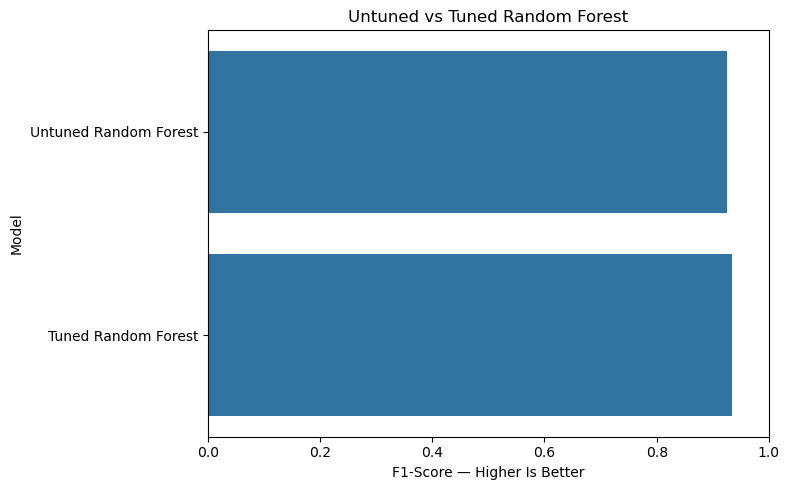

In [93]:
## Compare untuned and tuned F1-scores

plt.figure(figsize=(8, 5))

sns.barplot(
    data=tuning_comparison,
    x="F1 Score",
    y="Model"
)

plt.title(
    "Untuned vs Tuned Random Forest"
)

plt.xlabel(
    "F1-Score — Higher Is Better"
)

plt.ylabel("Model")

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

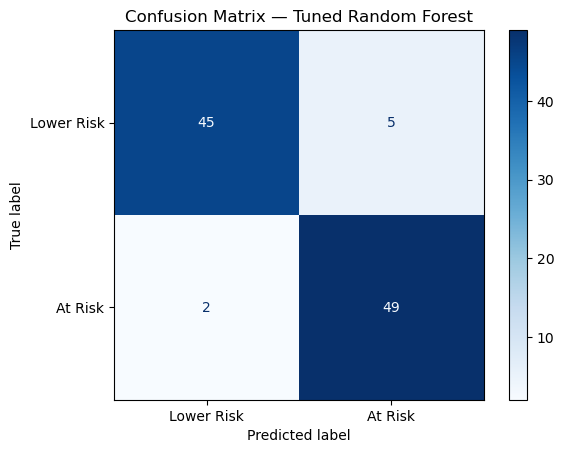

In [94]:
## Display confusion matrix for tuned model

tuned_confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(
        y_test,
        tuned_predictions
    ),
    display_labels=[
        "Lower Risk",
        "At Risk"
    ]
)

tuned_confusion_display.plot(
    cmap="Blues"
)

plt.title(
    "Confusion Matrix — Tuned Random Forest"
)

plt.show()

In [95]:
## Display detailed tuned-model performance

print(
    classification_report(
        y_test,
        tuned_predictions,
        target_names=[
            "Lower Risk",
            "At Risk"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Lower Risk       0.96      0.90      0.93        50
     At Risk       0.91      0.96      0.93        51

    accuracy                           0.93       101
   macro avg       0.93      0.93      0.93       101
weighted avg       0.93      0.93      0.93       101



In [96]:
## Create feature-importance table

feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tuned_random_forest.feature_importances_
})


## Sort from most to least important

feature_importance_df = (
    feature_importance_df
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)


top_features = feature_importance_df.head(15)

top_features

,Feature,Importance
0,numerical__Total Stress Score,0.159461
1,numerical__Pressure Satisfaction Gap,0.143374
2,categorical__Suicidal Thoughts_No,0.109158
3,categorical__Suicidal Thoughts_Yes,0.104680
4,numerical__Academic Pressure,0.095519
5,numerical__Age,0.082120
6,numerical__Study Satisfaction,0.056821
7,numerical__Study Hours,0.055070
8,numerical__Financial Stress,0.045533
9,categorical__Study Load Category_Low,0.021761


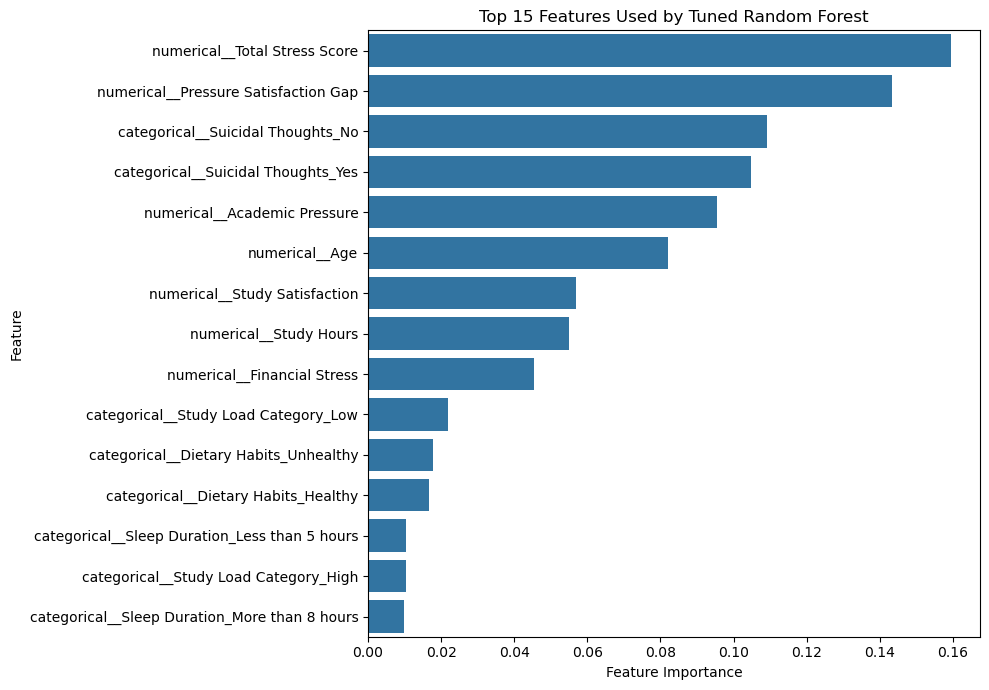

In [97]:
## Visualise the 15 most important features

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Features Used by Tuned Random Forest"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [98]:
## Select the tuned Random Forest as final model

final_model = tuned_random_forest

print(
    "Final model selected: Tuned Random Forest"
)

print(
    "Final F1-score:",
    round(tuned_f1, 4)
)

print(
    "Final recall:",
    round(tuned_recall, 4)
)

print(
    "Final ROC-AUC:",
    round(tuned_roc_auc, 4)
)

Final model selected: Tuned Random Forest
Final F1-score: 0.9333
Final recall: 0.9608
Final ROC-AUC: 0.9816


In [99]:
## Import joblib

import joblib


## Save the final classification model

joblib.dump(
    final_model,
    "depression_prediction_model.pkl"
)


## Save the fitted preprocessing object

joblib.dump(
    preprocessor,
    "depression_preprocessor.pkl"
)


print(
    "Model saved as depression_prediction_model.pkl"
)

print(
    "Preprocessor saved as depression_preprocessor.pkl"
)

Model saved as depression_prediction_model.pkl
Preprocessor saved as depression_preprocessor.pkl
